In [1]:
import pandas as pd
from sklearn.datasets import load_digits

digits = load_digits()

digits.target
dir(digits)
digits.target_names

df = pd.DataFrame(digits.data, digits.target)
df.head()

df['target'] = digits.target
df.head(20)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('target', axis='columns'),
    df.target,
    test_size=0.3
)

from sklearn.svm import SVC

rbf_model = SVC(kernel='rbf')

len(X_train)
len(X_test)

rbf_model.fit(X_train, y_train)
rbf_model.score(X_test, y_test)

linear_model = SVC(kernel='linear')
linear_model.fit(X_train, y_train)
linear_model.score(X_test, y_test)

0.9796296296296296

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("iris (1).csv")

X = df.drop("species", axis=1)
y = df["species"]

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

linear_model = SVC(kernel='linear')
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Linear Kernel Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_linear))

rbf_model = SVC(kernel='rbf')
rbf_model.fit(X_train, y_train)

y_pred_rbf = rbf_model.predict(X_test)

print("RBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("RBF Kernel Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rbf))

Linear Kernel Accuracy: 0.9333333333333333
Linear Kernel Confusion Matrix:
[[ 9  0  0]
 [ 0 10  2]
 [ 0  0  9]]
RBF Kernel Accuracy: 0.9333333333333333
RBF Kernel Confusion Matrix:
[[ 9  0  0]
 [ 0 10  2]
 [ 0  0  9]]


Accuracy: 0.593
Confusion Matrix:
[[133   0   0   0   0   0   3   2   0   1   0   0   2   0   3   0   0   0
    4   0   0   0   0   2   0   0]
 [  0  43   0  17   0   0  28   5   4   0   0   0   0   0  33   6   0  18
    4   0   0   0   0   4   0   0]
 [  0   0 118   0   9   0   7   4   0   0   0   4   1   0   6   0   0   0
    0   0   5   3   0   0   0   0]
 [  0   3   0 110   0   0  18  10   1   1   0   0   1   1  12   0   0   0
    0   0   0   0   0   1   0   1]
 [  0   1  31   0  15   8  10   4   2   0   4   2   0   0  32   0   1  12
    2   3   0   0   0   5   0   9]
 [  0   1   0   1   2  47  19   6   8   4   0   0   0   0  11  24   0   0
    5  12   0  13   1   5   2   0]
 [  0   0  22   0   1   0  26  28   0   0   2   3   0   0  51   1  16  15
    4   0   0   0   1   0   0   0]
 [  5   2   0   2   0   0  12  49   0   2   2   0   2  11  36   1   0  10
    0   0   5   1   0   1   0   0]
 [  0   1   0   0   1   0   6   0 125   1   0   0   0   0   2   2   2   0
    2   0   0   0   

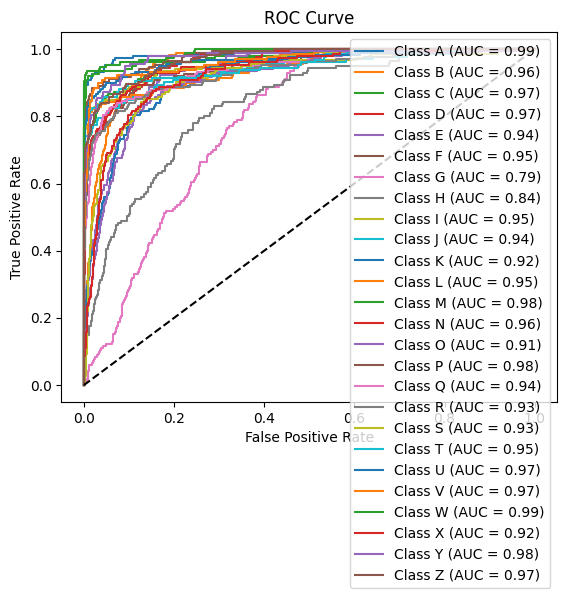

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

df = pd.read_excel("letter-recognition.xlsx")

X = df.drop("letter", axis=1)
y = df["letter"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2)

model = OneVsRestClassifier(SVC(kernel='linear', probability=True))
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
y_score = model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(le.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(le.classes_)):
    plt.plot(fpr[i], tpr[i], label="Class %s (AUC = %0.2f)" % (le.classes_[i], roc_auc[i]))

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Accuracy: 0.99675
Confusion Matrix:
[[3851    0]
 [  13  136]]
AUC Score: 0.9998832343730122


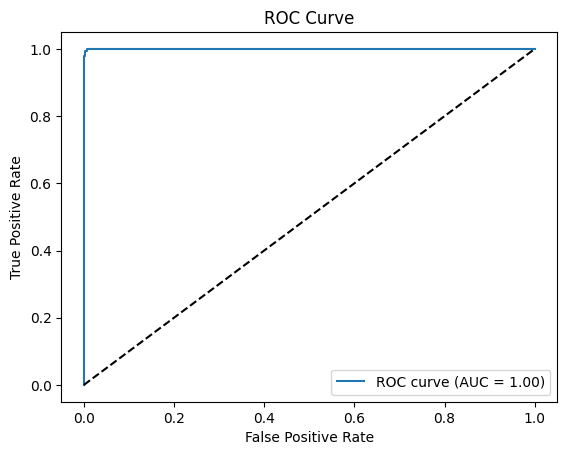

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

df = pd.read_excel("letter-recognition.xlsx")

X = df.drop("letter", axis=1)
y = df["letter"]

y = (y == 'A').astype(int)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = SVC(kernel='rbf', probability=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()